Data Loaded: (8000, 128, 128, 1) (8000, 128, 128, 4)


C:\Users\manju\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9692 - dice_coefficient: 0.9464 - loss: 0.1462

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Epoch 1 Prediction Unique Labels: [0]


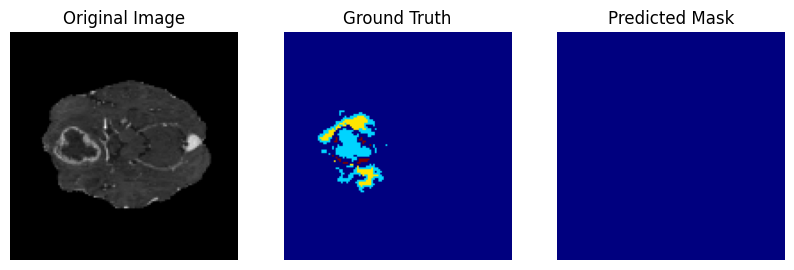

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 125s 119ms/step - accuracy: 0.9692 - dice_coefficient: 0.9464 - loss: 0.1461 - val_accuracy: 0.9781 - val_dice_coefficient: 0.9763 - val_loss: 0.1121 - learning_rate: 0.0010
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

Epoch 2 Prediction Unique Labels: [0]


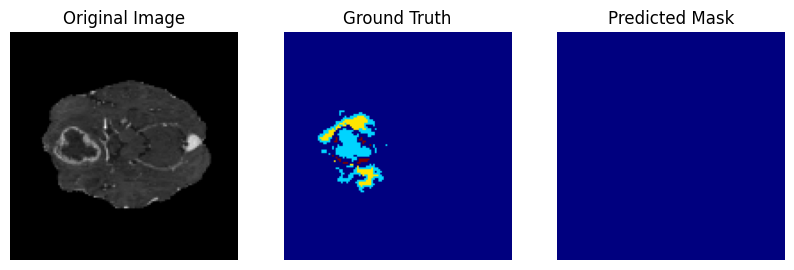

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 115s 115ms/step - accuracy: 0.9777 - dice_coefficient: 0.9758 - loss: 0.1142 - val_accuracy: 0.9781 - val_dice_coefficient: 0.9763 - val_loss: 0.1121 - learning_rate: 0.0010
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

Epoch 3 Prediction Unique Labels: [0]


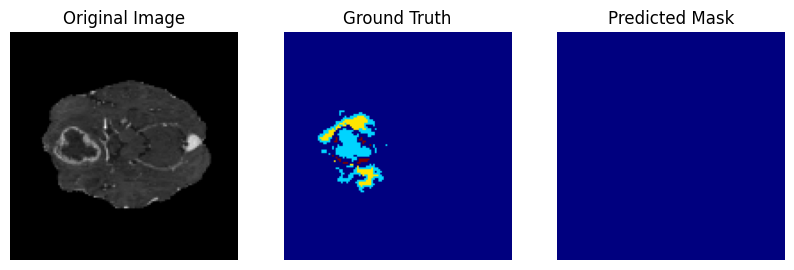

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 114s 114ms/step - accuracy: 0.9779 - dice_coefficient: 0.9760 - loss: 0.1132 - val_accuracy: 0.9781 - val_dice_coefficient: 0.9763 - val_loss: 0.1121 - learning_rate: 0.0010
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Epoch 4 Prediction Unique Labels: [0]


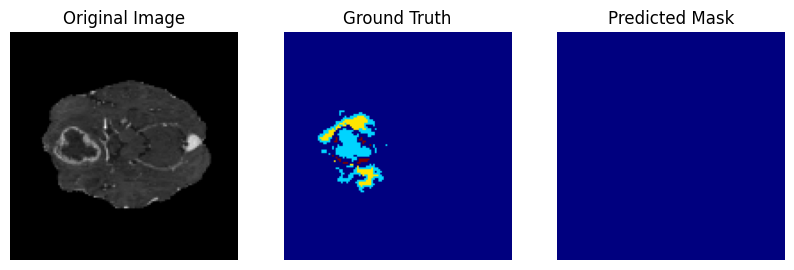

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 114s 114ms/step - accuracy: 0.9778 - dice_coefficient: 0.9760 - loss: 0.1133 - val_accuracy: 0.9781 - val_dice_coefficient: 0.9763 - val_loss: 0.1121 - learning_rate: 0.0010
Epoch 5/15
  44/1000 ━━━━━━━━━━━━━━━━━━━━ 1:37 102ms/step - accuracy: 0.9771 - dice_coefficient: 0.9754 - loss: 0.1170

KeyboardInterrupt: 

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
import numpy as np
import matplotlib.pyplot as plt

# =======================
# 1. Custom Metrics & Losses
# =======================
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = K.cast(y_true, 'float32')  # Ensure float type
    y_pred = K.cast(y_pred, 'float32')
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    y_pred = K.clip(y_pred, K.epsilon(), 1. - K.epsilon())
    cross_entropy = -y_true * K.log(y_pred)
    weight = alpha * K.pow((1 - y_pred), gamma)
    return K.sum(weight * cross_entropy, axis=-1)

def combined_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + K.mean(focal_loss(y_true, y_pred))

# =======================
# 2. Build Lightweight U-Net (slightly deeper)
# =======================
def build_unet(input_shape=(128,128,1), num_classes=4):
    inputs = layers.Input(input_shape)

    # Encoder
    c1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2))(c2)

    c3 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2,2))(c3)

    # Bottleneck
    b = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p3)
    b = layers.Conv2D(128, (3,3), activation='relu', padding='same')(b)

    # Decoder
    u1 = layers.UpSampling2D((2,2))(b)
    u1 = layers.concatenate([u1, c3])
    c4 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(u1)
    c4 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c4)

    u2 = layers.UpSampling2D((2,2))(c4)
    u2 = layers.concatenate([u2, c2])
    c5 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(u2)
    c5 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(c5)

    u3 = layers.UpSampling2D((2,2))(c5)
    u3 = layers.concatenate([u3, c1])
    c6 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(u3)
    c6 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(c6)

    outputs = layers.Conv2D(num_classes, (1,1), activation='softmax')(c6)
    return models.Model(inputs, outputs)

# =======================
# 3. Load Data
# =======================
data = np.load("brats_preprocessed.npz")
X_train = data["X_train"][:8000]
Y_train = data["Y_train"][:8000]
X_val = data["X_val"][:1000]
Y_val = data["Y_val"][:1000]

print("Data Loaded:", X_train.shape, Y_train.shape)

# =======================
# 4. Data Augmentation
# =======================
datagen = tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=15,
                                                          width_shift_range=0.05,
                                                          height_shift_range=0.05,
                                                          zoom_range=0.1,
                                                          horizontal_flip=True)
datagen.fit(X_train)

# =======================
# 5. Callbacks (Prediction + LR Scheduler)
# =======================
class PredictionCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        sample = X_val[0:1]
        gt = np.argmax(Y_val[0], axis=-1)
        pred = self.model.predict(sample)
        mask = np.argmax(pred, axis=-1)[0]

        print(f"\nEpoch {epoch+1} Prediction Unique Labels: {np.unique(mask)}")

        plt.figure(figsize=(10,4))
        plt.subplot(1,3,1)
        plt.imshow(sample[0,:,:,0], cmap='gray')
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.imshow(gt, cmap='jet')
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.imshow(mask, cmap='jet')
        plt.title("Predicted Mask")
        plt.axis("off")
        plt.show()

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
checkpoint = tf.keras.callbacks.ModelCheckpoint("unet_balanced.h5", save_best_only=True, monitor='val_loss')
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# =======================
# 6. Build & Compile Model
# =======================
model = build_unet()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=combined_loss,
              metrics=['accuracy', dice_coefficient])

# =======================
# 7. Train Model
# =======================
history = model.fit(datagen.flow(X_train, Y_train, batch_size=8),
                    validation_data=(X_val, Y_val),
                    epochs=15,
                    callbacks=[checkpoint, early_stop, reduce_lr, PredictionCallback()])
